<div align="center">
    <h1>📊 Flipkart Mobile Sales Analysis</h1>
</div>


## Import Required Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt 
import seaborn as sns
import re
import requests
from bs4 import BeautifulSoup

In [2]:
headers = {
    "User-Agent": "Mozilla/5.0"
}

In [3]:
url = 'http://flipkart.com/search?q=mobiles&otracker=search&otracker1=search&marketplace=FLIPKART&as-show=on&as=off&p%5B%5D=facets.price_range.from%3D10000&p%5B%5D=facets.price_range.to%3DMax&page=2'
page = requests.get(url, headers=headers)
soup = BeautifulSoup(page.text,"html.parser")

In [4]:
page

<Response [200]>

In [6]:
Title = []
Ratings = []
rat_rev = []
Original = []
Selling = []
storage = []
Discount = []


for i in range(1,25):
    url = f'http://flipkart.com/search?q=mobiles&otracker=search&otracker1=search&marketplace=FLIPKART&as-show=on&as=off&p%5B%5D=facets.price_range.from%3D10000&p%5B%5D=facets.price_range.to%3DMax&page={i}'
    page = requests.get(url)
    soup = BeautifulSoup(page.text)

    flipkart_cards = soup.find_all("div", class_="nZIRY7")


    for card in flipkart_cards:
        #mobile_title
        title_tag = card.find('div',class_="RG5Slk")
        title = (title_tag.text.strip() if title_tag else np.nan)
        Title.append(title)
        
        #Rating
        rate_tag = card.find('div',class_="MKiFS6")
        rates = (rate_tag.text.strip() if rate_tag else np.nan)
        Ratings.append(rates)

        #number of ratings and reviews 
        rev_tag = card.find('span',class_ = 'PvbNMB')
        revs = rev_tag.text.strip() if rev_tag else np.nan
        rat_rev.append(revs)

        #original_price
        org_tag = card.find('div',class_="kRYCnD gxR4EY")
        org = org_tag.text.strip() if org_tag else np.nan
        Original.append(org)

        #selling_price
        sel_tag = card.find('div',class_="hZ3P6w DeU9vF")
        sel = sel_tag.text.strip() if sel_tag else np.nan
        Selling.append(sel)

        #Ram_Rom
        store_tag = card.find_all('li',class_="DTBslk")
        ram_rom_text = store_tag[0].text.strip()
        storage.append(ram_rom_text)

        # Discount
        dis_tag = card.find('div',class_ = "HQe8jr")
        dis = dis_tag.text.strip() if dis_tag else np.nan
        Discount.append(dis)

In [8]:
df = pd.DataFrame({'Mobile_Brand' :Title,
                   'Ratings':Ratings,
                   'Ratings_reviews':rat_rev,
                   'Original_price':Original, 
                   'Selling_price':Selling, 
                   'Storage':storage,
                   'Discount':Discount})

## Raw_Data After Extract from the Website

In [9]:
df

,Mobile_Brand,Ratings,Ratings_reviews,Original_price,Selling_price,Storage,Discount
0,OPPO K13x 5G 6000mAh and 45W SUPERVOOC Charger...,4.4,"22,077 Ratings & 1,683 Reviews","₹15,999","₹12,499",4 GB RAM | 128 GB ROM | Expandable Upto 2 TB,21% off
1,"Samsung Galaxy S24 5G Snapdragon (Onyx Black, ...",4.6,"51,482 Ratings & 2,819 Reviews","₹79,999","₹47,999",8 GB RAM | 256 GB ROM,40% off
2,"MOTOROLA g57 power 5G (Pantone Fluidity, 128 GB)",4.4,"10,505 Ratings & 570 Reviews","₹17,999","₹13,999",8 GB RAM | 128 GB ROM,22% off
3,MOTOROLA Edge 60 Fusion 5G (PANTONE Mykonos Bl...,4.4,"1,17,679 Ratings & 6,090 Reviews","₹25,999","₹21,999",8 GB RAM | 256 GB ROM | Expandable Upto 1 TB,15% off
4,"Samsung Galaxy S24 5G Snapdragon (Marble Gray,...",4.6,"51,482 Ratings & 2,819 Reviews","₹74,999","₹42,999",8 GB RAM | 128 GB ROM,42% off
...,...,...,...,...,...,...,...
571,Samsung Galaxy S24 5G Snapdragon (Cobalt Viole...,4.6,"51,482 Ratings & 2,819 Reviews","₹79,999","₹47,999",8 GB RAM | 256 GB ROM,40% off
572,"Samsung Galaxy S25 FE 5G (Jetblack, 128 GB)",4.6,60 Ratings & 4 Reviews,NaN,"₹59,999",8 GB RAM | 128 GB ROM,NaN
573,"Samsung Galaxy F55 5G (Apricot Crush, 128 GB)",4,"3,194 Ratings & 255 Reviews","₹28,999","₹26,899",8 GB RAM | 128 GB ROM | Expandable Upto 1 TB,7% off
574,"realme P3 Pro 5G (Saturn Brown, 128 GB)",4.4,"18,013 Ratings & 1,339 Reviews","₹28,999","₹19,999",8 GB RAM | 128 GB ROM,31% off


## Feature extraction

In [12]:
Brand = []
model =[]
Color = []

for p in Title:
    name_part = p.split("(")[0].strip()
    brand = p.split()[0]
    color = p[p.find('(')+1:p.find(',')].strip()
    model.append(name_part.split()[0] + " " + name_part.split()[1])
    Brand.append(brand)
    Color.append(color)
    



In [16]:
RAM = []
ROM = []

for text in storage:
    ram_match = re.search(r'(\d+\s*GB)\s*RAM', text)
    rom_match = re.search(r'(\d+\s*GB)\s*ROM', text)

    RAM.append(ram_match.group(1) if ram_match else None)
    ROM.append(rom_match.group(1) if rom_match else None)

In [18]:
df = pd.DataFrame({'Brand':Brand,
                   'Color':Color,
                   'Ratings':Ratings,
                   'Ratings_reviews':rat_rev,
                   'Original_price':Original, 
                   'Selling_price':Selling, 
                   'Ram':RAM,
                   'Rom':ROM,
                   'Discount':Discount,
                  'Model':model})

In [20]:
df

,Brand,Color,Ratings,Ratings_reviews,Original_price,Selling_price,Ram,Rom,Discount,Model
0,OPPO,Midnight Violet,4.4,"22,077 Ratings & 1,683 Reviews","₹15,999","₹12,499",4 GB,128 GB,21% off,OPPO K13x
1,Samsung,Onyx Black,4.6,"51,482 Ratings & 2,819 Reviews","₹79,999","₹47,999",8 GB,256 GB,40% off,Samsung Galaxy
2,MOTOROLA,Pantone Fluidity,4.4,"10,505 Ratings & 570 Reviews","₹17,999","₹13,999",8 GB,128 GB,22% off,MOTOROLA g57
3,MOTOROLA,PANTONE Mykonos Blue,4.4,"1,17,679 Ratings & 6,090 Reviews","₹25,999","₹21,999",8 GB,256 GB,15% off,MOTOROLA Edge
4,Samsung,Marble Gray,4.6,"51,482 Ratings & 2,819 Reviews","₹74,999","₹42,999",8 GB,128 GB,42% off,Samsung Galaxy
...,...,...,...,...,...,...,...,...,...,...
571,Samsung,Cobalt Violet,4.6,"51,482 Ratings & 2,819 Reviews","₹79,999","₹47,999",8 GB,256 GB,40% off,Samsung Galaxy
572,Samsung,Jetblack,4.6,60 Ratings & 4 Reviews,NaN,"₹59,999",8 GB,128 GB,NaN,Samsung Galaxy
573,Samsung,Apricot Crush,4,"3,194 Ratings & 255 Reviews","₹28,999","₹26,899",8 GB,128 GB,7% off,Samsung Galaxy
574,realme,Saturn Brown,4.4,"18,013 Ratings & 1,339 Reviews","₹28,999","₹19,999",8 GB,128 GB,31% off,realme P3


## Converting to Csv_file

In [22]:
df.to_csv('Flipkart_mobiles_file.csv', index=False)

In [23]:
file_path = r"C:\Users\santh\EDA PORJECTS\Flipkart_mobiles_file.csv"

In [24]:
df = pd.read_csv(file_path)

## Understanding about the data

In [25]:
df.head()

,Brand,Color,Ratings,Ratings_reviews,Original_price,Selling_price,Ram,Rom,Discount,Model
0,OPPO,Midnight Violet,4.4,"22,077 Ratings & 1,683 Reviews","₹15,999","₹12,499",4 GB,128 GB,21% off,OPPO K13x
1,Samsung,Onyx Black,4.6,"51,482 Ratings & 2,819 Reviews","₹79,999","₹47,999",8 GB,256 GB,40% off,Samsung Galaxy
2,MOTOROLA,Pantone Fluidity,4.4,"10,505 Ratings & 570 Reviews","₹17,999","₹13,999",8 GB,128 GB,22% off,MOTOROLA g57
3,MOTOROLA,PANTONE Mykonos Blue,4.4,"1,17,679 Ratings & 6,090 Reviews","₹25,999","₹21,999",8 GB,256 GB,15% off,MOTOROLA Edge
4,Samsung,Marble Gray,4.6,"51,482 Ratings & 2,819 Reviews","₹74,999","₹42,999",8 GB,128 GB,42% off,Samsung Galaxy


In [26]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 576 entries, 0 to 575
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Brand            576 non-null    object 
 1   Color            576 non-null    object 
 2   Ratings          576 non-null    float64
 3   Ratings_reviews  576 non-null    object 
 4   Original_price   564 non-null    object 
 5   Selling_price    576 non-null    object 
 6   Ram              563 non-null    object 
 7   Rom              576 non-null    object 
 8   Discount         557 non-null    object 
 9   Model            576 non-null    object 
dtypes: float64(1), object(9)
memory usage: 45.1+ KB


In [27]:
df.isnull().sum()

Brand               0
Color               0
Ratings             0
Ratings_reviews     0
Original_price     12
Selling_price       0
Ram                13
Rom                 0
Discount           19
Model               0
dtype: int64

In [28]:
(df.isnull().sum() / len(df)) * 100

Brand              0.000000
Color              0.000000
Ratings            0.000000
Ratings_reviews    0.000000
Original_price     2.083333
Selling_price      0.000000
Ram                2.256944
Rom                0.000000
Discount           3.298611
Model              0.000000
dtype: float64

## Data cleaning

In [81]:
df = df.dropna()
df.isnull().sum()


Brand             0
Color             0
Ratings           0
Original_price    0
Selling_price     0
Ram               0
Rom               0
Discount          0
Model             0
Num_of_ratings    0
Num_of_reviews    0
Discount_money    0
dtype: int64

In [31]:
df['Original_price'] = (df['Original_price'].str.replace('₹', '', regex=False).str.replace(',', '', regex=False).astype(int))
df['Selling_price'] = (df['Selling_price'].str.replace('₹', '', regex=False).str.replace(',', '', regex=False).astype(int))


In [32]:
df['Discount'] = (df['Discount'].str.replace('% off', '', regex=False).astype(int))
df['Ram'] = df['Ram'].str.extract(r'(\d+)').astype(int)
df['Rom'] = df['Rom'].str.extract(r'(\d+)').astype(int)



In [33]:
df[['Num_of_ratings', 'Num_of_reviews']] = (df['Ratings_reviews'].str.replace(',', '', regex=True).str.extract(r'(\d+)\s+Ratings\s+&\s+(\d+)\s+Reviews').astype(int))

df.drop(columns='Ratings_reviews', inplace=True)


In [37]:
df['Brand'] = df['Brand'].str.upper()
df['Model'] = df['Model'].str.upper()

In [38]:
df.head()

,Brand,Color,Ratings,Original_price,Selling_price,Ram,Rom,Discount,Model,Num_of_ratings,Num_of_reviews
0,OPPO,Midnight Violet,4.4,15999,12499,4,128,21,OPPO K13X,22077,1683
1,SAMSUNG,Onyx Black,4.6,79999,47999,8,256,40,SAMSUNG GALAXY,51482,2819
2,MOTOROLA,Pantone Fluidity,4.4,17999,13999,8,128,22,MOTOROLA G57,10505,570
3,MOTOROLA,PANTONE Mykonos Blue,4.4,25999,21999,8,256,15,MOTOROLA EDGE,117679,6090
4,SAMSUNG,Marble Gray,4.6,74999,42999,8,128,42,SAMSUNG GALAXY,51482,2819


In [39]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 550 entries, 0 to 575
Data columns (total 11 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Brand           550 non-null    object 
 1   Color           550 non-null    object 
 2   Ratings         550 non-null    float64
 3   Original_price  550 non-null    int64  
 4   Selling_price   550 non-null    int64  
 5   Ram             550 non-null    int64  
 6   Rom             550 non-null    int64  
 7   Discount        550 non-null    int64  
 8   Model           550 non-null    object 
 9   Num_of_ratings  550 non-null    int64  
 10  Num_of_reviews  550 non-null    int64  
dtypes: float64(1), int64(7), object(3)
memory usage: 51.6+ KB


In [41]:
df.describe()

,Ratings,Original_price,Selling_price,Ram,Rom,Discount,Num_of_ratings,Num_of_reviews
count,550.000000,550.000000,550.000000,550.000000,550.000000,550.000000,550.000000,550.000000
mean,4.455091,44033.547273,30872.909091,7.970909,196.421818,24.123636,30554.841818,1736.776364
std,0.152578,27336.024876,17004.759295,2.205943,85.742170,12.891702,35354.348784,1857.265159
min,4.000000,11999.000000,10499.000000,4.000000,64.000000,1.000000,10.000000,0.000000
25%,4.400000,19499.000000,15998.250000,8.000000,128.000000,13.000000,3634.000000,209.000000
50%,4.400000,33999.000000,27999.000000,8.000000,128.000000,21.000000,18943.000000,1489.500000
75%,4.600000,74999.000000,42999.000000,8.000000,256.000000,40.000000,51482.000000,2819.000000
max,4.800000,176999.000000,161999.000000,16.000000,512.000000,42.000000,259008.000000,12768.000000


## 📊 Exploratory Data Analysis

In [82]:
plt.figure(figsize=(8,5))
sns.set(style="whitegrid")

<Figure size 800x500 with 0 Axes>

## Average Selling Price by RAM & ROM Configurations


In [43]:
ram_price = df.groupby('Ram')['Selling_price'].mean()
ram_price.head()

Ram
4     11926.773585
6     14139.985294
8     33988.447592
12    43052.855072
16    59699.000000
Name: Selling_price, dtype: float64

In [71]:
rom_price = df.groupby('Rom')['Selling_price'].mean()
rom_price.head()

Rom
64     11474.000000
128    22836.245675
256    38898.796680
512    54603.722222
Name: Selling_price, dtype: float64

# Top 5 Most Listed Brands on Flipkart

In [44]:
x=df["Brand"].value_counts(ascending=False)[0:20].reset_index()
x.columns = ["Brand", "Selling Values"]
x.head()

,Brand,Selling Values
0,SAMSUNG,211
1,REALME,85
2,POCO,42
3,MOTOROLA,40
4,OPPO,40


## Market Dominance Based on Product Availability

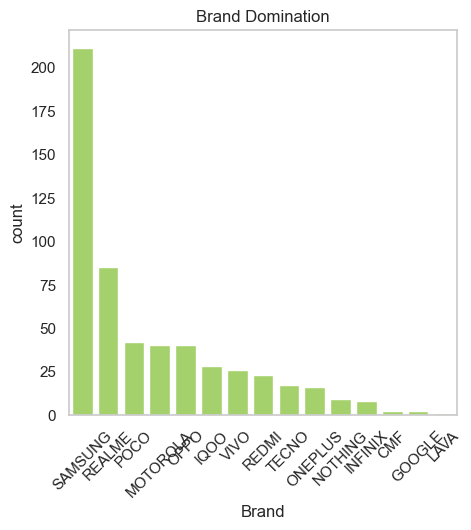

In [46]:
plt.figure(figsize=(5,5))
sns.countplot(data=df, x='Brand', order=df['Brand'].value_counts().index,color='#a6e25a')
plt.title("Brand Domination")
plt.xticks(rotation=45)
plt.grid(False) 
plt.show()





## Top 5 most-reviewed models

In [47]:
top_models = df.sort_values(by='Num_of_reviews', ascending=False)
top_models.head()

,Brand,Color,Ratings,Original_price,Selling_price,Ram,Rom,Discount,Model,Num_of_ratings,Num_of_reviews
425,MOTOROLA,Cobalt Blue,4.4,20999,15999,8,128,23,MOTOROLA G85,259008,12768
363,MOTOROLA,Brilliant Blue,4.3,14999,11999,8,128,20,MOTOROLA G45,251617,12421
433,MOTOROLA,Viva Magenta,4.3,14999,11999,8,128,20,MOTOROLA G45,251617,12421
278,MOTOROLA,Hot Pink,4.4,27999,20999,12,256,25,MOTOROLA EDGE,172840,11431
504,MOTOROLA,Forest Blue,4.4,27999,20999,12,256,25,MOTOROLA EDGE,172840,11431


## All top 5 most-reviewed models are from MOTOROLA
## Models like:
* MOTOROLA G85 
* MOTOROLA G45
* MOTOROLA EDGE
### Have 12K+ customer reviews each
### Priced mainly in the ₹11,000 – ₹21,000 range
### Ratings are consistently above 4.3 

# RAM & ROM Distribution

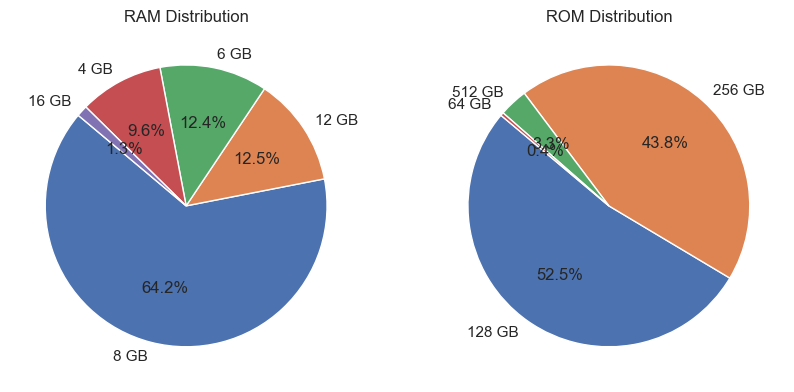

In [48]:
ram_counts = df['Ram'].value_counts()
rom_counts = df['Rom'].value_counts()
fig, ax = plt.subplots(1, 2, figsize=(10,6))

ax[0].pie(
    ram_counts.values,
    labels=ram_counts.index.astype(str) + " GB",
    autopct='%1.1f%%',
    startangle=140,
    wedgeprops={'edgecolor': 'white'}
)
ax[0].set_title("RAM Distribution")

ax[1].pie(
    rom_counts.values,
    labels=rom_counts.index.astype(str) + " GB",
    autopct='%1.1f%%',
    startangle=140,
    wedgeprops={'edgecolor': 'white'}
)
ax[1].set_title("ROM Distribution")

plt.show()


## 8GB RAM dominates the market
## 128GB & 256GB storage is the most preferred configuration.

 # Top 5 Most Listed Mobile Colors on Flipkart

In [49]:
color_counts = df['Color'].value_counts().reset_index()
color_counts.columns = ['Color', 'Count']

color_counts.head()


,Color,Count
0,Onyx Black,51
1,Marble Gray,48
2,Cobalt Violet,48
3,Amber Yellow,24
4,Midnight Violet,24


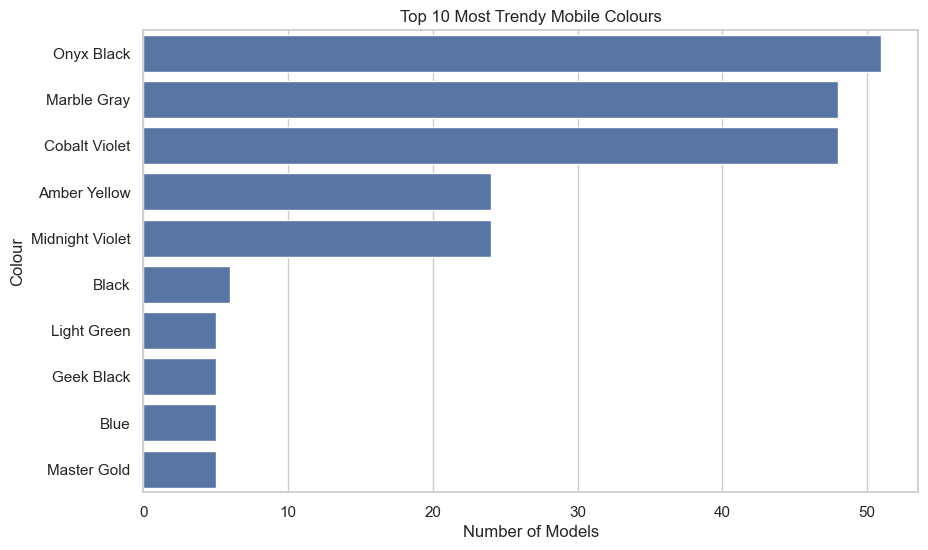

In [50]:
top_colors = df['Color'].value_counts().head(10)

plt.figure(figsize=(10,6),)
sns.barplot(
    x=top_colors.values,
    y=top_colors.index,
)

plt.title("Top 10 Most Trendy Mobile Colours")
plt.xlabel("Number of Models")
plt.ylabel("Colour")
plt.show()


In [51]:
color_summary = (
    df.groupby('Color')
    .agg(
        Model_Count=('Model','count'),
        Avg_Rating=('Ratings','mean'),
        Total_Ratings=('Num_of_ratings','sum'),
        Total_Reviews = ('Num_of_reviews','sum')
    )
    .sort_values('Model_Count', ascending=False)
    .head(10)
)

color_summary


,Model_Count,Avg_Rating,Total_Ratings,Total_Reviews
Color,,,,
Onyx Black,51,4.582353,2484916,135878
Marble Gray,48,4.600000,2471136,135312
Cobalt Violet,48,4.600000,2471136,135312
Amber Yellow,24,4.600000,1235568,67656
Midnight Violet,24,4.400000,529848,40392
Black,6,4.366667,83874,5645
Geek Black,5,4.400000,18290,1950
Light Green,5,4.180000,81389,5350
Blue,5,4.340000,150410,9555


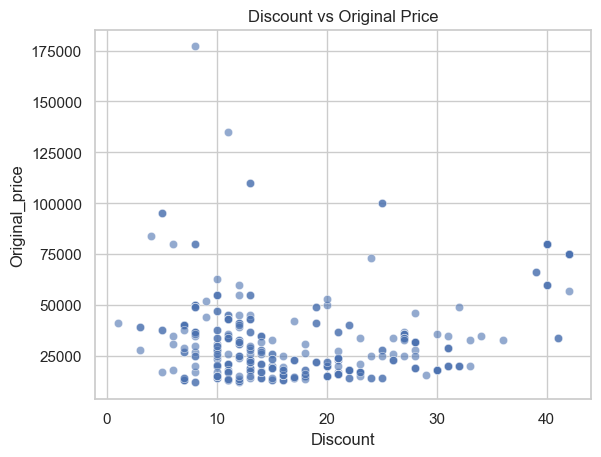

In [52]:
sns.scatterplot(data=df, x='Discount', y='Original_price', alpha=0.6)
plt.title("Discount vs Original Price")
plt.show()


### Higher discounts appear mostly in mid-range phones

# Most Costly Model per Brand

In [55]:
most_costly_model = df.loc[
    df.groupby("Brand")["Selling_price"].idxmax()
]


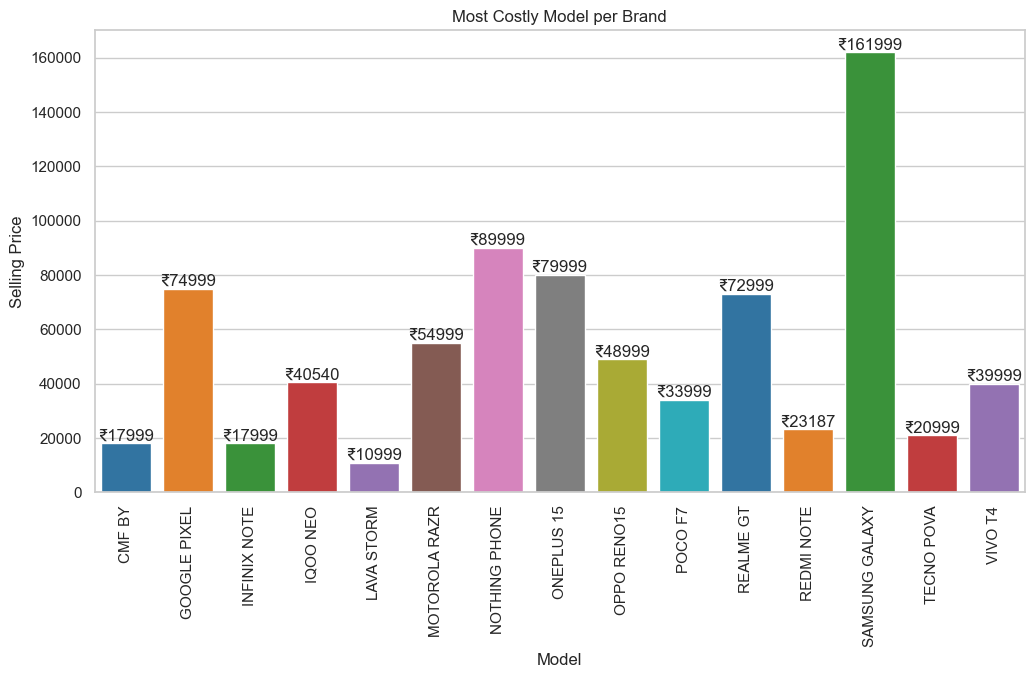

In [56]:
plt.figure(figsize=(12,6))

ax = sns.barplot(
    x="Model",
    y="Selling_price",
    hue="Model",     
    data=most_costly_model,
    palette="tab10",
    legend=False          
)

plt.xticks(rotation=90)
plt.title("Most Costly Model per Brand")
plt.xlabel("Model")
plt.ylabel("Selling Price")

for i, value in enumerate(most_costly_model["Selling_price"]):
    ax.text(i, value, f"₹{value}", ha="center", va="bottom")

plt.show()


# Selling & Original Price Distribution 

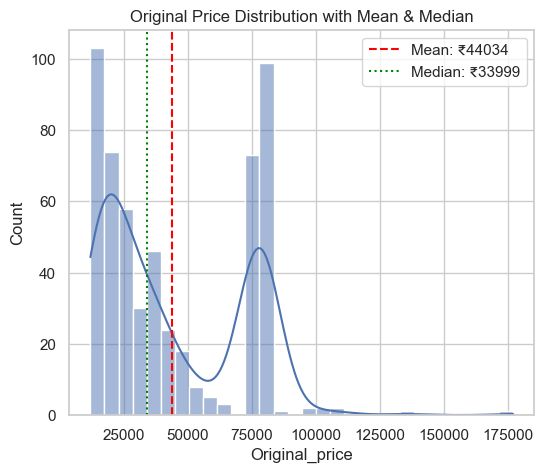

In [57]:
mean_price = df['Original_price'].mean()
median_price = df['Original_price'].median()

plt.figure(figsize=(6,5))
sns.histplot(df['Original_price'], bins=30, kde=True)

plt.axvline(mean_price, color='red', linestyle='--', label=f'Mean: ₹{mean_price:.0f}')
plt.axvline(median_price, color='green', linestyle=':', label=f'Median: ₹{median_price:.0f}')

plt.title("Original Price Distribution with Mean & Median")
plt.legend()
plt.show()


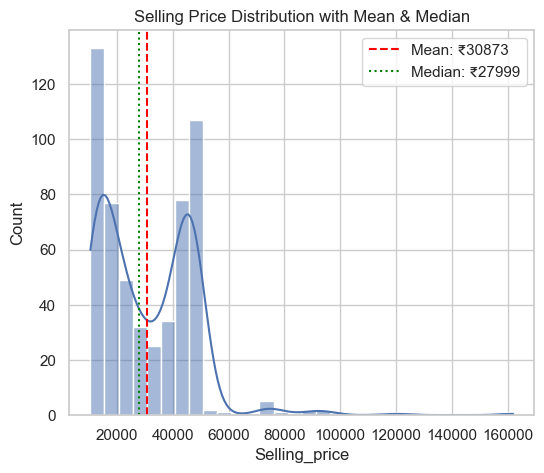

In [58]:
mean_price = df['Selling_price'].mean()
median_price = df['Selling_price'].median()

plt.figure(figsize=(6,5))
sns.histplot(df['Selling_price'], bins=30, kde=True)

plt.axvline(mean_price, color='red', linestyle='--', label=f'Mean: ₹{mean_price:.0f}')
plt.axvline(median_price, color='green', linestyle=':', label=f'Median: ₹{median_price:.0f}')

plt.title("Selling Price Distribution with Mean & Median")
plt.legend()
plt.show()


### Top 10 Mobile Models With Highest Ratings

In [59]:
top10_models = df.nlargest(10,"Ratings")
top10_models

,Brand,Color,Ratings,Original_price,Selling_price,Ram,Rom,Discount,Model,Num_of_ratings,Num_of_reviews
165,OPPO,Twilight Blue,4.8,54999,48999,12,256,10,OPPO RENO15,59,9
166,OPPO,Aurora Blue,4.8,54999,48999,12,256,10,OPPO RENO15,59,9
167,OPPO,Glacier White,4.8,54999,48999,12,256,10,OPPO RENO15,59,9
539,REDMI,Black,4.8,26999,23187,8,128,14,REDMI NOTE,10,0
550,REALME,Diary White,4.8,79999,72999,12,256,8,REALME GT,53,28
551,REALME,Urban Blue,4.8,79999,72999,12,256,8,REALME GT,53,28
122,OPPO,Glacier White,4.7,49999,45999,8,256,8,OPPO RENO15,164,47
145,POCO,Frost Silver,4.7,22999,19999,8,128,13,POCO M8,482,33
152,POCO,Glacial Blue,4.7,22999,19999,8,128,13,POCO M8,482,33
158,SAMSUNG,Silver Shadow,4.7,99999,74999,12,256,25,SAMSUNG GALAXY,320,42


## Impact of RAM and ROM on Customer Reviews & Ratings

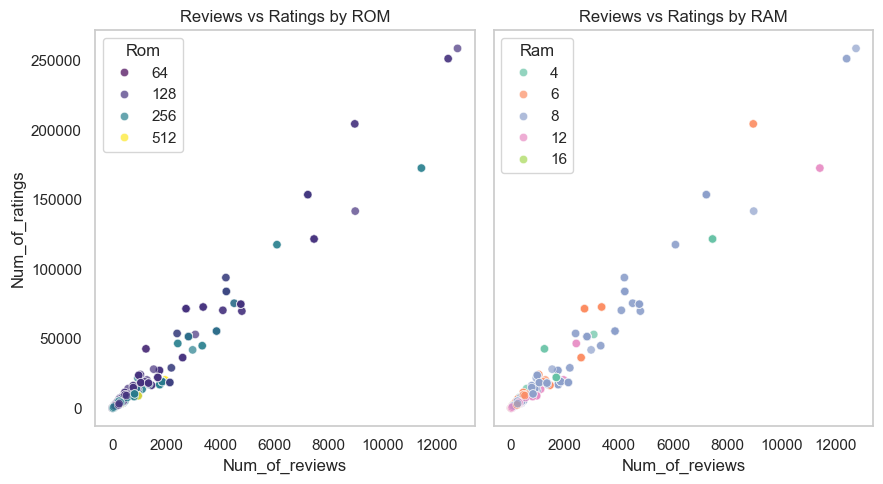

In [73]:
fig, axes = plt.subplots(1, 2, figsize=(9,5), sharey=True)

# Scatter 1: ROM
sns.scatterplot(data=df,x='Num_of_reviews', y='Num_of_ratings',hue='Rom',palette='viridis',alpha=0.7, ax=axes[0]
)
axes[0].set_title("Reviews vs Ratings by ROM")
axes[0].grid(False)

# Scatter 2: RAM
sns.scatterplot(data=df, x='Num_of_reviews',y='Num_of_ratings',hue='Ram',palette='Set2',alpha=0.7,ax=axes[1]
)
axes[1].set_title("Reviews vs Ratings by RAM")
axes[1].grid(False)

plt.tight_layout()
plt.show()


### 128 GB ROM mobiles have the highest customer engagement.
### 8 GB RAM models are the most popular among users.
### Customers mostly prefer balanced configurations like 8 GB RAM + 128 GB ROM.

## Mobile Price Distribution Across Budget and Premium Segments

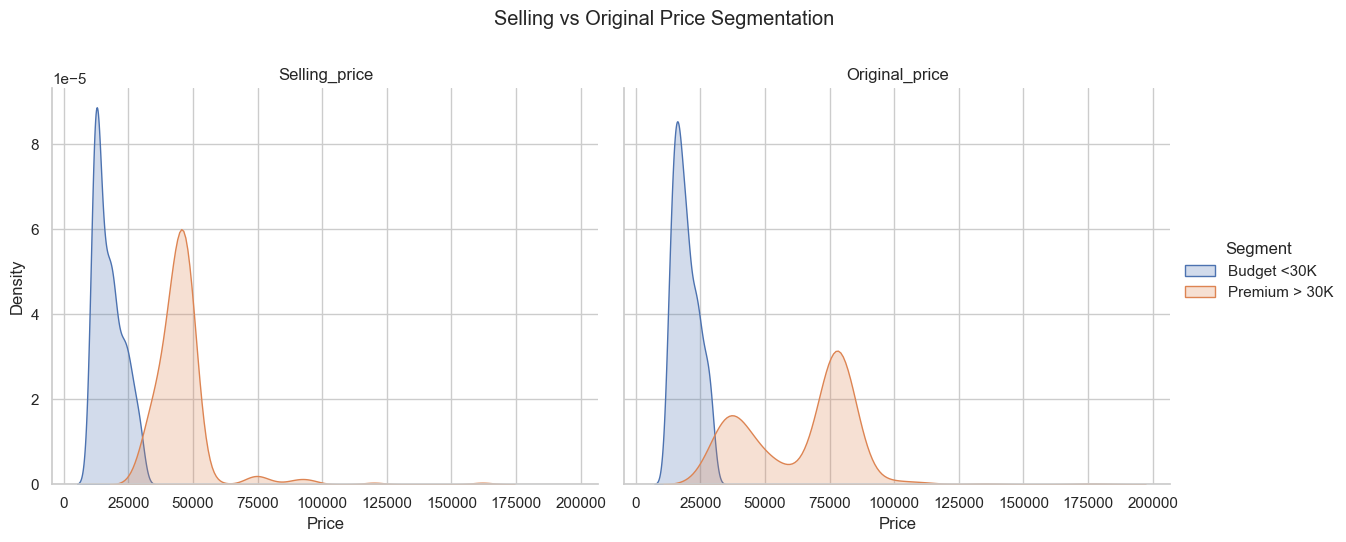

In [78]:
price_df = pd.melt(
    df,
    value_vars=['Selling_price', 'Original_price'],
    var_name='Price_Type',
    value_name='Price'
)

price_df['Segment'] = np.where(price_df['Price'] < 30000,
                               'Budget <30K', 'Premium > 30K')

g = sns.FacetGrid(
    price_df,
    col="Price_Type",
    hue="Segment",
    height=5,
    aspect=1.2,
    sharex=True
)

g.map(sns.kdeplot, "Price", fill=True)
g.add_legend()
g.set_titles("{col_name}")
g.fig.suptitle("Selling vs Original Price Segmentation", y=1.08)

plt.show()


### 1. This graph compares selling price and original price of mobile phones by dividing them into two segments: below ₹30,000 and above ₹30,000.
### 2. For both selling and original prices, most phones are concentrated below ₹30,000, showing that budget phones dominate the market.
### 3. Phones priced above ₹30,000 are fewer but spread across a wider price range, which represents premium and flagship models.
### 4. The gap between original and selling price in the premium segment indicates that higher-priced phones usually get bigger discounts.

## Comparison of Average Discounts Across Mobile Brands

In [79]:
brand_avg_discount = (
    df.groupby("Brand")["Discount"]
    .mean()
    .sort_values(ascending=False)
)

dis = brand_avg_discount
dis

Brand
SAMSUNG     37.236967
REDMI       21.173913
CMF         21.000000
OPPO        19.350000
POCO        18.738095
LAVA        18.000000
MOTOROLA    17.650000
TECNO       17.176471
REALME      15.600000
GOOGLE      13.000000
VIVO        11.961538
ONEPLUS     11.250000
IQOO        10.571429
INFINIX     10.250000
NOTHING      9.333333
Name: Discount, dtype: float64

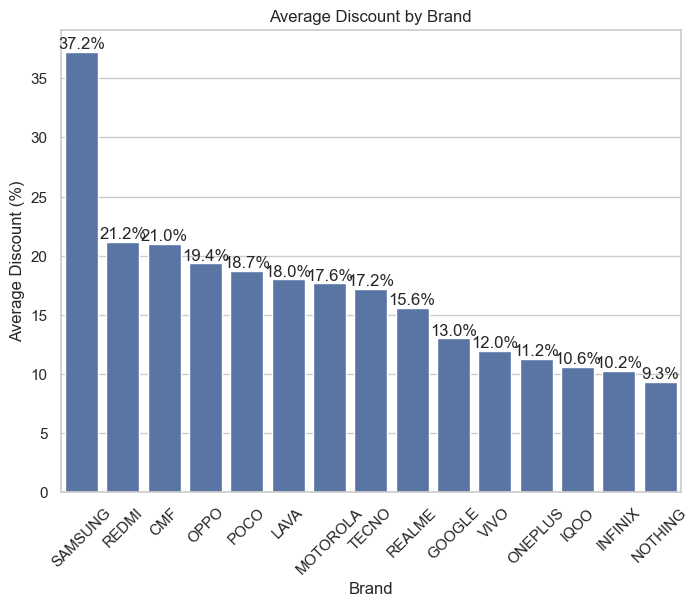

In [80]:
plt.figure(figsize=(8,6))

ax = sns.barplot(
    x=dis.index,
    y=dis.values
)

plt.title("Average Discount by Brand")
plt.xlabel("Brand")
plt.ylabel("Average Discount (%)")
plt.xticks(rotation=45)

for i, v in enumerate(dis.values):
    ax.text(i, v, f"{v:.1f}%", ha="center", va="bottom")

plt.show()


## Understanding Key Relationships in Mobile Sales Data

In [64]:
corr_matrix = df.corr(numeric_only=True)
corr_matrix

,Ratings,Original_price,Selling_price,Ram,Rom,Discount,Num_of_ratings,Num_of_reviews
Ratings,1.000000,0.695648,0.633303,0.315407,0.241544,0.434081,0.218355,0.214345
Original_price,0.695648,1.000000,0.934574,0.382127,0.363983,0.677652,0.240732,0.245642
Selling_price,0.633303,0.934574,1.000000,0.547163,0.517322,0.393289,0.092836,0.095598
Ram,0.315407,0.382127,0.547163,1.000000,0.671257,-0.098896,-0.106468,-0.102574
Rom,0.241544,0.363983,0.517322,0.671257,1.000000,-0.097100,-0.106339,-0.093194
Discount,0.434081,0.677652,0.393289,-0.098896,-0.097100,1.000000,0.413154,0.430530
Num_of_ratings,0.218355,0.240732,0.092836,-0.106468,-0.106339,0.413154,1.000000,0.979780
Num_of_reviews,0.214345,0.245642,0.095598,-0.102574,-0.093194,0.430530,0.979780,1.000000


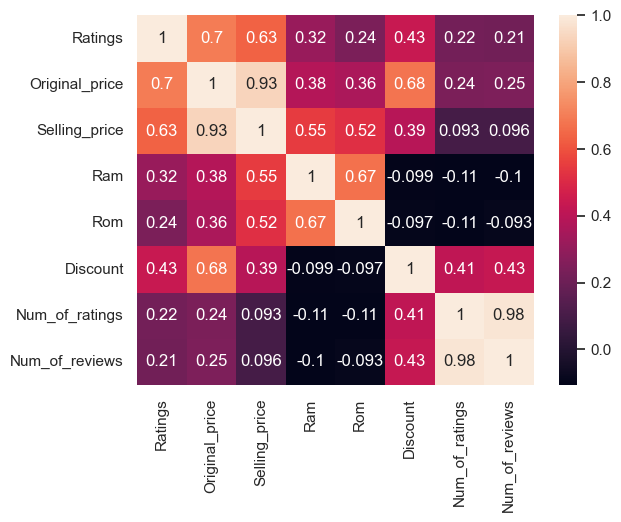

In [65]:
sns.heatmap(corr_matrix,annot=True)
plt.show()

## 🔑 Key Insights of the Complete Project
* Mid-Range Phones Dominate the Market.
* Motorola Leads in Customer Engagement.
* Samsung Uses Aggressive Discount Strategy.
* Selling Price Closely Follows Original Price.
* Premium models help branding, but mid-range models drive revenue.
  

## Business Recommendation
+ Focus more on mid-range phones (₹10K–₹30K) because most customers buy in this range.
+ Promote phones with high reviews and ratings, as customers trust other users.
+ Use discounts wisely, especially for expensive phones to attract buyers.
+ Offer balanced specs like 8GB RAM and 128GB/256GB storage instead of extreme features.
+ Build value-for-money products, not just premium ones.
+ Use customer feedback to improve products and marketing.
+ Price phones competitively based on market data.